# Pharmacy Network & Channel Optimization: Classical Model (v0.5)

**What changed in v0.5.** The data layer is now the reference script's own generator, lifted function for
function: same 1000 members, same 50 pharmacies, same seed 7, same Minneapolis geography, same haversine
distances, same eligibility rules, same current pharmacy assignment. Both models now run on one identical
dataset, so any difference in results is the model, not the data.

**Structure.** Section 2a is reference code, unchanged. Section 2b runs it. Section 2c adds only what our
richer model needs as extra columns on the same roster. Everything after that is our model.

**How to read this notebook. Three tags:**
- **[CONFIG]** the dials. Client facing settings. Change these, never the model.
- **[INPUT]** data the model consumes.
- **[OUTPUT]** what the model hands back.

## 0. Packages and solver

```
pip install pyomo highspy pyscipopt pandas numpy matplotlib
```

**Solver.** HiGHS via Pyomo `appsi_highs`, exact MIP, proven optimal. The reference script uses PuLP with CBC;
both are exact, so results are comparable. Pyomo is used here because the identical model object also runs on
SCIP or Gurobi unchanged, and maps one to one onto the D-Wave hybrid CQM solver.

In [1]:
# !pip install pyomo highspy pyscipopt pandas numpy matplotlib
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2
from pyomo.environ import (ConcreteModel, Var, Objective, Constraint, ConstraintList,
                           Binary, NonNegativeReals, minimize, value, SolverFactory)
rng = np.random.default_rng(42)
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 26)
print('imports OK')

imports OK


## 1. [CONFIG]: the dials

Only the disruption weight is a price between competing interests. The steering weights are the reference
script's scenario parameters. Access floors are set to levels the data can attain (Section 2e verifies this
before solving), with the retail lens applied to standard members, the specialty lens to specialty members,
and the infusion lens to infused volume.

In [2]:
CONFIG = {
    'LAMBDA_D'        : 20.0,
    'LAMBDA_SWEEP'    : [0, 20, 200],
    'CONTRACT_WEIGHT' : 2.5,
    'DISTANCE_PENALTY': 0.05,
    'EXTRA_CHOICE_REWARD'   : 0.0,
    'CURRENT_NETWORK_REWARD': 0.0,
    'CURRENT_SITE_REWARD_SCALE': 250.0,
    'RETAIL_FLOORS'  : {'urban': 0.85, 'rural': 0.95},   # over standard members, weighted
    'SPEC_FLOOR'     : 0.90,
    'INF_FLOOR'      : 0.90,
    'INF_RADIUS'     : 40.0,
    'QUALITY_FLOOR'  : 4.0,
    'COVERAGE_BONUS' : 1.0,
    'AWP_STATES'     : {'STATE_B'},
    'GAMMA'          : None,
    'PRIORITY'       : 'cost_1A',
}
CONFIG

{'LAMBDA_D': 20.0,
 'LAMBDA_SWEEP': [0, 20, 200],
 'CONTRACT_WEIGHT': 2.5,
 'DISTANCE_PENALTY': 0.05,
 'EXTRA_CHOICE_REWARD': 0.0,
 'CURRENT_NETWORK_REWARD': 0.0,
 'CURRENT_SITE_REWARD_SCALE': 250.0,
 'RETAIL_FLOORS': {'urban': 0.85, 'rural': 0.95},
 'SPEC_FLOOR': 0.9,
 'INF_FLOOR': 0.9,
 'INF_RADIUS': 40.0,
 'QUALITY_FLOOR': 4.0,
 'COVERAGE_BONUS': 1.0,
 'AWP_STATES': {'STATE_B'},
 'GAMMA': None,
 'PRIORITY': 'cost_1A'}

## 2a. Reference data layer, lifted

These five functions are the reference script's, reproduced unchanged in behaviour: haversine distance,
member and pharmacy simulation (seed 7), the long form distance table with eligibility and nearby flags,
current pharmacy assignment inside today's network, and coverability flags.

In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    """Compute Haversine distance in miles."""
    R = 3958.8
    dlat = radians(lat2 - lat1); dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2*atan2(sqrt(a), sqrt(1-a))
    return R*c

def simulate_data(n_members=1000, n_pharmacies=50, center_lat=44.9778, center_lon=-93.2650, seed=7):
    """Simulate members and pharmacies."""
    np.random.seed(seed)
    member_ids = [f"M{i:03d}" for i in range(n_members)]
    mail_count = max(1, int(round(0.05*n_members)))
    speciality_count = max(1, int(round(0.08*n_members)))
    sampled = np.random.permutation(member_ids)
    mail_member_ids = set(sampled[:mail_count])
    speciality_member_ids = set(sampled[mail_count:mail_count+speciality_count])
    members = pd.DataFrame({
        "member_id": member_ids,
        "lat": center_lat + np.random.uniform(-0.25, 0.25, n_members),
        "lon": center_lon + np.random.uniform(-0.35, 0.35, n_members),
        "setting": np.random.choice(["urban","rural"], size=n_members, p=[0.7,0.3]),
        "utilization_weight": np.random.uniform(0.5, 2.0, n_members)})
    members["MailOrderIndicator"] = members["member_id"].isin(mail_member_ids)
    members["SpecialityInd"]      = members["member_id"].isin(speciality_member_ids)
    members["VisitNumber"]        = np.random.randint(1, 11, n_members)
    members["threshold_miles"]    = members["setting"].map({"urban":4.0, "rural":15.0})
    pharmacy_ids = [f"P{j:02d}" for j in range(n_pharmacies)]
    oh_count = max(1, int(round(0.10*n_pharmacies)))
    spec_count = max(1, int(round(0.10*n_pharmacies)))
    closed_count = max(1, int(round(0.02*n_pharmacies)))
    shuffled = np.random.permutation(pharmacy_ids)
    oh_ids = set(shuffled[:oh_count]); spec_ids = set(shuffled[oh_count:oh_count+spec_count])
    closed_ids = set(np.random.choice(pharmacy_ids, size=closed_count, replace=False))
    pharmacies = pd.DataFrame({
        "pharmacy_id": pharmacy_ids,
        "lat": center_lat + np.random.uniform(-0.28, 0.28, n_pharmacies),
        "lon": center_lon + np.random.uniform(-0.38, 0.38, n_pharmacies),
        "network_cost": np.random.randint(8, 30, n_pharmacies),
        "contract_pct": np.random.randint(75, 96, n_pharmacies),
        "chain": np.random.choice(["ChainA","ChainB","ChainC","Independent"],
                                  size=n_pharmacies, p=[0.3,0.25,0.2,0.25]),
        "in_current_network": np.random.choice([0,1], size=n_pharmacies, p=[0.45,0.55])})
    pharmacies["pharmacy_type"] = "Retail"
    pharmacies.loc[pharmacies["pharmacy_id"].isin(oh_ids), "pharmacy_type"] = "OptumHomeDelivery"
    pharmacies.loc[pharmacies["pharmacy_id"].isin(spec_ids), "pharmacy_type"] = "Speciality"
    pharmacies["marker_code"] = pharmacies["pharmacy_type"].map(
        {"OptumHomeDelivery":"OH", "Speciality":"S", "Retail":"R"})
    pharmacies["AcceptNewPatients"] = ~pharmacies["pharmacy_id"].isin(closed_ids)
    return members, pharmacies

def build_distance_matrix(members, pharmacies, nearby_factor=1.25):
    """Create long-form distance table with eligibility flags."""
    records = []; lookup = members.set_index("member_id")
    for _, m in members.iterrows():
        for _, p in pharmacies.iterrows():
            d = haversine_miles(m["lat"], m["lon"], p["lat"], p["lon"])
            threshold = lookup.loc[m["member_id"], "threshold_miles"]
            is_mail = bool(lookup.loc[m["member_id"], "MailOrderIndicator"])
            is_spec = bool(lookup.loc[m["member_id"], "SpecialityInd"])
            base_eligible = int(d <= threshold)
            if is_mail:
                eligible = int(p["pharmacy_type"] == "OptumHomeDelivery"); nearby = 0
            elif is_spec:
                eligible = int((p["pharmacy_type"]=="Speciality") and (d <= threshold))
                nearby   = int((p["pharmacy_type"]=="Speciality") and (d <= threshold*nearby_factor))
            else:
                eligible = base_eligible; nearby = int(d <= threshold*nearby_factor)
            records.append({"member_id": m["member_id"], "pharmacy_id": p["pharmacy_id"],
                            "distance_miles": d, "eligible": eligible, "nearby": nearby})
    return pd.DataFrame(records)

def assign_current_pharmacy(members, pharmacies, dist_df):
    """Assign a simulated current pharmacy for each member."""
    current_ids = pharmacies.loc[pharmacies["in_current_network"]==1, "pharmacy_id"].tolist()
    oh_ids = pharmacies.loc[pharmacies["pharmacy_type"]=="OptumHomeDelivery", "pharmacy_id"]
    cmap = {}
    for _, m in members.iterrows():
        m_id = m["member_id"]; rows = dist_df[dist_df["member_id"]==m_id]
        if bool(m["MailOrderIndicator"]):
            elig = rows[(rows["pharmacy_id"].isin(current_ids)) &
                        (rows["pharmacy_id"].isin(oh_ids))].sort_values("distance_miles")
        else:
            elig = rows[(rows["pharmacy_id"].isin(current_ids)) &
                        (rows["eligible"]==1)].sort_values("distance_miles")
        if len(elig) > 0: cmap[m_id] = elig.iloc[0]["pharmacy_id"]
        else:
            any_ = (rows[rows["pharmacy_id"].isin(oh_ids)] if bool(m["MailOrderIndicator"])
                    else rows[rows["eligible"]==1]).sort_values("distance_miles")
            cmap[m_id] = any_.iloc[0]["pharmacy_id"] if len(any_) > 0 else None
    members = members.copy(); members["current_pharmacy"] = members["member_id"].map(cmap)
    return members

def add_coverability_flags(members, dist_df):
    """Add whether member is coverable by at least one pharmacy."""
    coverable = dist_df.groupby("member_id")["eligible"].sum().rename("eligible_count").reset_index()
    members = members.merge(coverable, on="member_id", how="left")
    members["eligible_count"] = members["eligible_count"].fillna(0)
    members["coverable"] = members["eligible_count"] > 0
    return members
print('reference data layer loaded')

reference data layer loaded


## 2b. [INPUT] Run the reference pipeline

Identical to the reference script's main(): simulate, distances, current pharmacy, coverability. Members
without any eligible pharmacy are flagged uncoverable and excluded from routing, exactly as the reference
model does.

In [4]:
members, pharmacies = simulate_data()
dist_df  = build_distance_matrix(members, pharmacies)
members  = assign_current_pharmacy(members, pharmacies, dist_df)
members  = add_coverability_flags(members, dist_df)
print(f"members {len(members)} | pharmacies {len(pharmacies)} | distance rows {len(dist_df):,}")
print("pharmacy types:", pharmacies.pharmacy_type.value_counts().to_dict())
print(f"in current network: {int(pharmacies.in_current_network.sum())} | closed to new patients: {int((~pharmacies.AcceptNewPatients).sum())}")
print(f"coverable members: {int(members.coverable.sum())} of {len(members)}")
uncov = members.loc[~members.coverable, ['member_id','setting','lat','lon']]
if len(uncov): print(f"WARNING: {len(uncov)} members are not coverable under current rules (reference behaviour)")
members.head(3)

members 1000 | pharmacies 50 | distance rows 50,000
pharmacy types: {'Retail': 40, 'Speciality': 5, 'OptumHomeDelivery': 5}
in current network: 25 | closed to new patients: 1
coverable members: 852 of 1000


,member_id,lat,lon,setting,utilization_weight,MailOrderIndicator,SpecialityInd,VisitNumber,threshold_miles,current_pharmacy,eligible_count,coverable
0,M000,45.047166,-93.087451,rural,1.557347,False,False,2,15.0,P45,26,True
1,M001,44.740272,-92.959426,urban,1.685826,False,False,4,4.0,P35,3,True
2,M002,44.897527,-93.077723,urban,1.709223,False,False,8,4.0,NaN,0,False


## 2c. Extension layer on the same roster

Only additive columns, no regeneration. state supports the any willing pharmacy mandate; quality supports the
quality floor; capacity supports the capacity constraint; chain_rule turns the reference chain labels into
contracting rules; cost_factor carries site of care economics. Infusion sites are appended because the
reference roster has none and the infused class requires them.

In [5]:
ph = pharmacies.copy()
ph['state']      = np.where(ph.lon < -93.30, 'STATE_A', np.where(ph.lon < -93.20, 'STATE_B', 'STATE_C'))
ph['quality']    = np.round(rng.uniform(3.5, 5.0, len(ph)), 1)
ph['capacity']   = rng.uniform(2500, 9000, len(ph)).astype(int)
ph['chain_rule'] = ph.chain.map({'ChainA':'=', 'ChainB':'=', 'ChainC':'<=', 'Independent':'<='})
ph['cost_factor']= 1.0
ph.loc[ph.pharmacy_type=='OptumHomeDelivery', 'capacity'] = 10_000_000
ph.loc[ph.pharmacy_type=='OptumHomeDelivery', 'cost_factor'] = 0.90
inf_rows = []
for i,(stype, cf) in enumerate([('hospital_opd',1.60), ('infusion_center',1.00), ('infusion_center',1.00),
                                ('physician_office',1.15), ('home_infusion',0.90)]):
    a = members.sample(1, random_state=100+i).iloc[0]
    inf_rows.append(dict(pharmacy_id=f'INF{i}', lat=float(a.lat), lon=float(a.lon),
        network_cost=int(rng.uniform(18,30)), contract_pct=int(rng.integers(78,95)),
        chain='INF_NET', in_current_network=1, pharmacy_type=stype, marker_code='I',
        AcceptNewPatients=True, state='STATE_B', quality=round(float(rng.uniform(4.0,5.0)),1),
        capacity=1200, chain_rule='<=', cost_factor=cf))
ph = pd.concat([ph, pd.DataFrame(inf_rows)], ignore_index=True).set_index('pharmacy_id')
INF_TYPES = ['hospital_opd','infusion_center','physician_office','home_infusion']
RET = [p for p in ph.index if ph.loc[p,'pharmacy_type']=='Retail']
SPE = [p for p in ph.index if ph.loc[p,'pharmacy_type']=='Speciality']
OH  = [p for p in ph.index if ph.loc[p,'pharmacy_type']=='OptumHomeDelivery']
INF = [p for p in ph.index if ph.loc[p,'pharmacy_type'] in INF_TYPES]
SITES = ph.index.tolist()
print(f"roster: {len(RET)} retail | {len(OH)} home delivery | {len(SPE)} specialty | {len(INF)} infusion (added)")
ph.groupby('pharmacy_type').agg(n=('network_cost','size'), contract_pct=('contract_pct','mean'),
                                quality=('quality','mean'), cost_factor=('cost_factor','mean')).round(2)

roster: 40 retail | 5 home delivery | 5 specialty | 5 infusion (added)


,n,contract_pct,quality,cost_factor
pharmacy_type,,,,
OptumHomeDelivery,5,81.80,3.76,0.90
Retail,40,85.22,4.38,1.00
Speciality,5,85.20,4.26,1.00
home_infusion,1,89.00,4.30,0.90
hospital_opd,1,86.00,4.30,1.60
infusion_center,2,90.00,4.55,1.00
physician_office,1,85.00,4.90,1.15


## 2d. Drug class catalog

Eligibility uses the reference script's pharmacy_type vocabulary. Interaction rule: the member level mail and
specialty flags govern classes servable at retail, while a class that requires specialty or infusion sites
overrides them, since an infused biologic cannot be mailed.

In [6]:
classes = pd.DataFrame([
 ('ACUTE_ANTIINF', 0.18,'oral',      35,  ['Retail'],                          False,'rx'),
 ('CARDIO_STATIN', 0.26,'oral',      18,  ['Retail','OptumHomeDelivery'],      False,'rx'),
 ('DIABETES_ORAL', 0.12,'oral',      22,  ['Retail','OptumHomeDelivery'],      False,'rx'),
 ('INSULIN',       0.08,'inj_cold',  210, ['Retail','OptumHomeDelivery'],      False,'rx'),
 ('INFLAM_ORAL',   0.20,'oral',      28,  ['Retail','OptumHomeDelivery'],      False,'rx'),
 ('INFLAM_BIO_PEN',0.06,'pen_cold',  3800,['Speciality'],                      True, 'rx'),
 ('ONCOLOGY_ORAL', 0.04,'oral_spec', 7500,['Speciality'],                      True, 'rx'),
 ('INFUSED_BIO',   0.06,'infusion',  5200, INF_TYPES,                          True, 'dual'),
], columns=['class_id','share','form','base_cost','eligible','spec_lens','benefit']).set_index('class_id')
assert abs(classes.share.sum()-1.0) < 1e-9
K = classes.index.tolist()
classes

,share,form,base_cost,eligible,spec_lens,benefit
class_id,,,,,,
ACUTE_ANTIINF,0.18,oral,35,[Retail],False,rx
CARDIO_STATIN,0.26,oral,18,"[Retail, OptumHomeDelivery]",False,rx
DIABETES_ORAL,0.12,oral,22,"[Retail, OptumHomeDelivery]",False,rx
INSULIN,0.08,inj_cold,210,"[Retail, OptumHomeDelivery]",False,rx
INFLAM_ORAL,0.20,oral,28,"[Retail, OptumHomeDelivery]",False,rx
INFLAM_BIO_PEN,0.06,pen_cold,3800,[Speciality],True,rx
ONCOLOGY_ORAL,0.04,oral_spec,7500,[Speciality],True,rx
INFUSED_BIO,0.06,infusion,5200,"[hospital_opd, infusion_center, physician_offi...",True,dual


## 2e. Derived structures, lenses, and the feasibility pre check

Claim volume per member and class uses the reference weighting (utilization_weight times VisitNumber) split by
class share. Routing sets combine the reference eligibility flags with class eligibility. Continuity: a
member's current pharmacy is always kept in their routing set, so they may stay with it whenever it is
selected. Access lenses are applied to the population each one governs: retail to standard members, specialty
to specialty members, infusion to infused volume. The pre check reports the ceiling each lens can reach before
any solve.

In [7]:
mem = members.set_index('member_id')
COV   = mem[mem.coverable].index.tolist()
STD   = [m for m in COV if not mem.loc[m,'MailOrderIndicator'] and not mem.loc[m,'SpecialityInd']]
SPECM = [m for m in COV if mem.loc[m,'SpecialityInd']]
MAILM = [m for m in COV if mem.loc[m,'MailOrderIndicator']]
CLAIMS = {(m,k): mem.loc[m,'utilization_weight']*mem.loc[m,'VisitNumber']*classes.loc[k,'share'] for m in COV for k in K}
cost_kp = {(k,p): classes.loc[k,'base_cost']*ph.loc[p,'cost_factor'] for k in K for p in SITES}
D = {(r.member_id, r.pharmacy_id): r.distance_miles for r in dist_df.itertuples()}
for m in COV:
    for p in INF: D[(m,p)] = haversine_miles(mem.loc[m,'lat'], mem.loc[m,'lon'], ph.loc[p,'lat'], ph.loc[p,'lon'])
elig_pair = {(r.member_id, r.pharmacy_id): r.eligible for r in dist_df.itertuples()}
near_pair = {(r.member_id, r.pharmacy_id): r.nearby   for r in dist_df.itertuples()}

A = {}
for m in COV:
    is_mail = bool(mem.loc[m,'MailOrderIndicator'])
    for k in K:
        et = classes.loc[k,'eligible']
        if any(t in INF_TYPES for t in et):
            opts = sorted([p for p in INF if ph.loc[p,'pharmacy_type'] in et], key=lambda p: D[(m,p)])[:4]
        elif 'Speciality' in et:
            opts = [p for p in SPE if elig_pair.get((m,p),0)==1] or sorted(SPE, key=lambda p: D[(m,p)])[:1]
        elif is_mail and 'OptumHomeDelivery' in et:
            opts = list(OH)
        else:
            opts = [p for p in RET if elig_pair.get((m,p),0)==1]
            if 'OptumHomeDelivery' in et: opts = opts + list(OH)
            if not opts: opts = sorted(RET, key=lambda p: D[(m,p)])[:1]
        cur = mem.loc[m,'current_pharmacy']          # continuity guarantee
        if cur is not None and cur in opts + [] and cur not in opts: opts.append(cur)
        if cur is not None and ph.loc[cur,'pharmacy_type'] in et and cur not in opts: opts.append(cur)
        A[(m,k)] = opts
YIDX = [(m,k,p) for (m,k),o in A.items() for p in o]

N_ret = {m: [p for p in RET if elig_pair.get((m,p),0)==1] for m in STD}
N_nearby = {m: [p for p in RET if near_pair.get((m,p),0)==1] for m in STD}
N_spe = {m: [p for p in SPE if elig_pair.get((m,p),0)==1] for m in SPECM}
N_inf = {m: [p for p in INF if D[(m,p)] <= CONFIG['INF_RADIUS']] for m in COV}
w_mem  = {m: mem.loc[m,'utilization_weight'] for m in COV}
spec_w = {m: sum(CLAIMS[(m,k)] for k in K if classes.loc[k,'spec_lens'] and classes.loc[k,'form']!='infusion') for m in COV}
inf_w  = {m: CLAIMS[(m,'INFUSED_BIO')] for m in COV}
TOT = sum(CLAIMS.values())

def coverage_rates(active):
    act = set(active); out = {}
    for s_ in ['urban','rural']:
        mm = [m for m in STD if mem.loc[m,'setting']==s_]
        out[f'retail_{s_}'] = sum(w_mem[m] for m in mm if any(p in act for p in N_ret[m]))/sum(w_mem[m] for m in mm)
    out['retail_all'] = sum(w_mem[m] for m in STD if any(p in act for p in N_ret[m]))/sum(w_mem[m] for m in STD)
    out['specialty']  = sum(spec_w[m] for m in SPECM if any(p in act for p in N_spe[m]))/sum(spec_w[m] for m in SPECM)
    out['infusion']   = sum(inf_w[m] for m in COV if any(p in act for p in N_inf[m]))/sum(inf_w.values())
    return out
CURRENT = [p for p in SITES if ph.loc[p,'in_current_network']==1]
coverage_before = coverage_rates(CURRENT)
att_all = coverage_rates(SITES)
print(f"coverable members {len(COV)} (standard {len(STD)}, specialty {len(SPECM)}, mail {len(MAILM)})")
print(f"(member,class) pairs {len(A):,} | y variables {len(YIDX):,} | avg options {len(YIDX)/len(A):.1f}")
print("\ncoverage before, today's network:", {k: round(v,3) for k,v in coverage_before.items()})
print("\nfeasibility pre check, ceiling vs required floor:")
for s_, f in CONFIG['RETAIL_FLOORS'].items():
    a_ = att_all[f'retail_{s_}']
    print(f"  retail {s_:6s}: ceiling {a_:.3f} vs floor {f:.2f} {'OK' if a_>=f else 'IMPOSSIBLE, lower the floor or fix data'}")
print(f"  specialty   : ceiling {att_all['specialty']:.3f} vs floor {CONFIG['SPEC_FLOOR']:.2f} {'OK' if att_all['specialty']>=CONFIG['SPEC_FLOOR'] else 'IMPOSSIBLE'}")
print(f"  infusion    : ceiling {att_all['infusion']:.3f} vs floor {CONFIG['INF_FLOOR']:.2f} {'OK' if att_all['infusion']>=CONFIG['INF_FLOOR'] else 'IMPOSSIBLE'}")

coverable members 852 (standard 771, specialty 31, mail 50)
(member,class) pairs 6,816 | y variables 45,570 | avg options 6.7

coverage before, today's network: {'retail_urban': np.float64(0.591), 'retail_rural': np.float64(1.0), 'retail_all': np.float64(0.734), 'specialty': np.float64(0.635), 'infusion': np.float64(1.0)}

feasibility pre check, ceiling vs required floor:
  retail urban : ceiling 0.882 vs floor 0.85 OK
  retail rural : ceiling 1.000 vs floor 0.95 OK
  specialty   : ceiling 1.000 vs floor 0.90 OK
  infusion    : ceiling 1.000 vs floor 0.90 OK


## 3. Decision variables

x[p] site in network, y[m,k,p] share of member m's class k volume routed to p, v[m] retail covered,
vs[m] specialty covered, vi[m] infusion covered, ws[m] two or more nearby retail options, z[c] chain participates.

In [8]:
mdl = ConcreteModel()
CH = ph.chain.unique().tolist()
mdl.x  = Var(SITES, within=Binary)
mdl.z  = Var(CH, within=Binary)
mdl.y  = Var(YIDX, within=NonNegativeReals, bounds=(0,1))
mdl.v  = Var(STD, within=Binary)
mdl.ws = Var(STD, within=Binary)
mdl.vs = Var(SPECM, within=Binary)
mdl.vi = Var(COV, within=Binary)
print(f"variables: x={len(SITES)}, z={len(CH)}, y={len(YIDX):,}, v={len(STD)}, ws={len(STD)}, vs={len(SPECM)}, vi={len(COV)}")

variables: x=55, z=5, y=45,570, v=771, ws=771, vs=31, vi=852


## 4. Objective

Drug cost, network administration, priced disruption, contract steering, distance price, choice reward,
current network reward, coverage bonus. Disruption is the only priced trade off between competing interests;
the steering terms are the reference script's scenario weights.

In [9]:
cur_of = {m: mem.loc[m,'current_pharmacy'] for m in COV}
# precompute per-variable coefficients once, so each scenario rebuild is a single pass
OH_set = set(OH)
C_cost = {t: CLAIMS[(t[0],t[1])]*cost_kp[(t[1],t[2])] for t in YIDX}
C_con  = {t: CLAIMS[(t[0],t[1])]*(100-ph.loc[t[2],'contract_pct'])/100.0 for t in YIDX}
C_dis  = {t: (0.0 if t[2] in OH_set else CLAIMS[(t[0],t[1])]*D[(t[0],t[2])]) for t in YIDX}
ADMIN  = {p: ph.loc[p,'network_cost']*1000 for p in SITES}
DISR_W = {m: w_mem[m]*mem.loc[m,'VisitNumber'] for m in COV if cur_of[m] is not None}
Q_OF   = {t: CLAIMS[(t[0],t[1])]*ph.loc[t[2],'quality'] for t in YIDX}
CP_OF  = {t: CLAIMS[(t[0],t[1])]*ph.loc[t[2],'contract_pct'] for t in YIDX}
TYPE_OF = ph.pharmacy_type.to_dict()
def cost_expr(m_):  return sum(C_cost[t]*m_.y[t] for t in YIDX)
def admin_expr(m_): return sum(ADMIN[p]*m_.x[p] for p in SITES)
def disr_expr(m_):  return sum(DISR_W[m]*(1-m_.x[cur_of[m]]) for m in DISR_W)
def set_objective(m_, P):
    if hasattr(m_,'obj'): m_.del_component(m_.obj)
    cw, dp = P['CONTRACT_WEIGHT'], P['DISTANCE_PENALTY']
    y_terms = sum((C_cost[t] + cw*C_con[t] + dp*C_dis[t]) * m_.y[t] for t in YIDX)
    m_.obj = Objective(expr=y_terms + admin_expr(m_)
                          + P['LAMBDA_D']*disr_expr(m_)
                          - P['EXTRA_CHOICE_REWARD']*sum(w_mem[m]*m_.ws[m] for m in STD)
                          - P['CURRENT_NETWORK_REWARD']*CONFIG['CURRENT_SITE_REWARD_SCALE']*sum(m_.x[p] for p in CURRENT)
                          - CONFIG['COVERAGE_BONUS']*(sum(w_mem[m]*m_.v[m] for m in STD)
                              + sum(spec_w[m]*m_.vs[m] for m in SPECM) + sum(inf_w[m]*m_.vi[m] for m in COV)),
                       sense=minimize)
set_objective(mdl, CONFIG); print('objective set (coefficients precomputed)')

objective set (coefficients precomputed)


## 5. Constraint 1: access, three lenses

A member counts as covered only when an in network site of the right kind is eligible for them. Retail floors
apply to standard members by setting, specialty to specialty members, infusion to infused volume. Enforced,
not merely reported.

In [10]:
mdl.cov = ConstraintList()
for m in STD:   mdl.cov.add(mdl.v[m]  <= (sum(mdl.x[p] for p in N_ret[m]) if N_ret[m] else 0))
for m in SPECM: mdl.cov.add(mdl.vs[m] <= (sum(mdl.x[p] for p in N_spe[m]) if N_spe[m] else 0))
for m in COV:   mdl.cov.add(mdl.vi[m] <= (sum(mdl.x[p] for p in N_inf[m]) if N_inf[m] else 0))
mdl.adeq = ConstraintList()
for s_, f in CONFIG['RETAIL_FLOORS'].items():
    mm = [m for m in STD if mem.loc[m,'setting']==s_]
    mdl.adeq.add(sum(w_mem[m]*mdl.v[m] for m in mm) >= f*sum(w_mem[m] for m in mm))
mdl.adeq.add(sum(spec_w[m]*mdl.vs[m] for m in SPECM) >= CONFIG['SPEC_FLOOR']*sum(spec_w[m] for m in SPECM))
mdl.adeq.add(sum(inf_w[m]*mdl.vi[m] for m in COV)    >= CONFIG['INF_FLOOR']*sum(inf_w.values()))
print('C1 added: coverage definitions + retail, specialty, infusion floors')

C1 added: coverage definitions + retail, specialty, infusion floors


## 6. Constraint 2: complete eligible routing, and choice richness

Every member and class volume goes somewhere, and only to in network sites. Eligibility is structural: y
variables exist only over eligible options, so a mail member cannot be routed to a storefront and an infused
drug cannot be routed to retail. The choice flag may switch on only with two or more nearby in network retail
options (reference script logic).

In [11]:
mdl.route = ConstraintList()
for (m,k),o in A.items(): mdl.route.add(sum(mdl.y[m,k,p] for p in o) == 1)
for (m,k,p) in YIDX:      mdl.route.add(mdl.y[m,k,p] <= mdl.x[p])
mdl.choice = ConstraintList()
for m in STD:
    if len(N_nearby[m]) >= 2: mdl.choice.add(2*mdl.ws[m] <= sum(mdl.x[p] for p in N_nearby[m]))
    else:                     mdl.choice.add(mdl.ws[m] == 0)
print('C2 added: completeness, linking, choice richness')

C2 added: completeness, linking, choice richness


## 7. Constraint 3: capacity, and AcceptNewPatients

No site takes more volume than it can dispense. Sites closed to new patients keep only their incumbent
members, adopted from the reference script.

In [12]:
mdl.cap = ConstraintList()
use = {p: [] for p in SITES}
for (m,k,p) in YIDX: use[p].append((m,k))
for p in SITES:
    if use[p]: mdl.cap.add(sum(CLAIMS[(m,k)]*mdl.y[m,k,p] for (m,k) in use[p]) <= ph.loc[p,'capacity']*mdl.x[p])
mdl.accept = ConstraintList(); locked = 0
for (m,k,p) in YIDX:
    if not ph.loc[p,'AcceptNewPatients'] and cur_of[m] != p:
        mdl.accept.add(mdl.y[m,k,p] == 0); locked += 1
print(f'C3 added: capacity | C3b: {locked} new patient routings locked at closed sites')

C3 added: capacity | C3b: 3388 new patient routings locked at closed sites


## 8. Constraint 4: chain contracting rules

All or nothing chains enter or exit together; opt in chains and independents may be selected store by store
inside a participating agreement.

In [13]:
mdl.chain = ConstraintList()
for p in SITES:
    r_, c_ = ph.loc[p,'chain_rule'], ph.loc[p,'chain']
    if r_ == '=':    mdl.chain.add(mdl.x[p] == mdl.z[c_])
    elif r_ == '<=': mdl.chain.add(mdl.x[p] <= mdl.z[c_])
print('C4 added: chain equality and opt in rules')

C4 added: chain equality and opt in rules


## 9. Constraint 5: mandates from location

Home delivery is PBM owned and always available. Any willing pharmacy statutes protect pharmacies willing to
remain in network: every retail site in an AWP state stays in. Production joins state against the real statute
table.

In [14]:
mdl.mandate = ConstraintList()
for p in OH: mdl.mandate.add(mdl.x[p] == 1)
P_must = [p for p in RET if ph.loc[p,'state'] in CONFIG['AWP_STATES']]
for p in P_must: mdl.mandate.add(mdl.x[p] == 1)
print(f"C5 added: {len(OH)} home delivery + {len(P_must)} retail sites mandated by any willing pharmacy law in {sorted(CONFIG['AWP_STATES'])}")

C5 added: 5 home delivery + 8 retail sites mandated by any willing pharmacy law in ['STATE_B']


## 10. Constraint 6: quality floor

Network quality weighted by where volume actually routes must clear the client bar.

In [15]:
mdl.quality = Constraint(expr=sum(Q_OF[t]*mdl.y[t] for t in YIDX) >= CONFIG['QUALITY_FLOOR']*TOT)
print('C6 added: volume weighted quality at least', CONFIG['QUALITY_FLOOR'])

C6 added: volume weighted quality at least 4.0


## 11. Constraints 7 to 9: benefit consistency, cost guarantee, formulary compliance

C7 holds by construction: infused volume routes only to infusion sites and spend is reported per benefit.
C8 caps spend at GAMMA times baseline when the client contract carries a guarantee, and a per scenario budget
cap mirrors the reference script. C9 enters through the data and is asserted here.

In [16]:
B0 = sum(CLAIMS[(m,k)]*cost_kp[(k,cur_of[m])] for m in COV for k in K
         if cur_of[m] is not None and ph.loc[cur_of[m],'pharmacy_type'] in classes.loc[k,'eligible'])
B0 += sum(CLAIMS[(m,k)]*cost_kp[(k,sorted(A[(m,k)], key=lambda p: D[(m,p)])[0])] for m in COV for k in K
          if cur_of[m] is None or ph.loc[cur_of[m],'pharmacy_type'] not in classes.loc[k,'eligible'])
if CONFIG['GAMMA'] is not None:
    mdl.guarantee = Constraint(expr=cost_expr(mdl) <= CONFIG['GAMMA']*B0)
def set_budget(m_, budget):
    if hasattr(m_,'budget_c'): m_.del_component(m_.budget_c)
    if budget is not None: m_.budget_c = Constraint(expr=cost_expr(m_) + admin_expr(m_) <= budget)
assert all(ph.loc[p,'pharmacy_type'] in classes.loc[k,'eligible'] for (m,k,p) in YIDX), 'C9 violated'
print(f"C7 by construction | C9 asserted | baseline spend B0 = {B0:,.0f}")

C7 by construction | C9 asserted | baseline spend B0 = 5,728,443


## 12. Solve: classical exact baseline

In [17]:
def solve(m_):
    opt = SolverFactory('appsi_highs')
    t0 = time.time(); res = opt.solve(m_); return res, time.time()-t0
res, dt = solve(mdl)
print(f"status: {res.solver.termination_condition} | solve time: {dt:.1f}s")

status: optimal | solve time: 6.4s


## 13. [OUTPUT] Results

Roster, routing by class and channel, economics versus today's spend, coverage before and after, disruption,
continuity, quality, and weighted assigned contract percentage.

In [18]:
def metrics(m_):
    sel = [p for p in SITES if round(value(m_.x[p]))==1]
    yv = {t: value(m_.y[t]) for t in YIDX}
    drug = sum(C_cost[t]*yv[t] for t in YIDX); admin = sum(ADMIN[p]*value(m_.x[p]) for p in SITES)
    disr_units = sum(w_mem[m]*mem.loc[m,'VisitNumber'] for m in COV if cur_of[m] is not None and round(value(m_.x[cur_of[m]]))==0)
    tot_units  = sum(w_mem[m]*mem.loc[m,'VisitNumber'] for m in COV if cur_of[m] is not None)
    YSET = set(YIDX)
    kept = sum(CLAIMS[(m,k)]*yv[(m,k,cur_of[m])] for m in COV for k in K
               if cur_of[m] is not None and (m,k,cur_of[m]) in YSET)
    qual = sum(Q_OF[t]*yv[t] for t in YIDX)/TOT
    wcon = sum(CP_OF[t]*yv[t] for t in YIDX)/TOT
    mix = {k: {} for k in K}
    for t in YIDX:
        mix[t[1]][TYPE_OF[t[2]]] = mix[t[1]].get(TYPE_OF[t[2]], 0) + CLAIMS[(t[0],t[1])]*yv[t]
    mix = {k: {tt: v/sum(d_.values()) for tt,v in d_.items()} for k,d_ in mix.items() for d_ in [mix[k]]}
    return dict(selected=sel, drug=drug, admin=admin, total=drug+admin,
                disr_pct=100*disr_units/tot_units, kept_pct=100*kept/TOT,
                quality=qual, contract_pct=wcon, cov_after=coverage_rates(sel), mix=mix)
M = metrics(mdl)
print(f"OUTPUT 1  roster: {len(M['selected'])} of {len(SITES)} sites in network")
print("\nOUTPUT 2  routing plan (channel mix per class):")
print(pd.DataFrame(M['mix']).T.fillna(0).round(2))
print(f"\nOUTPUT 3  economics: drug {M['drug']:,.0f} + admin {M['admin']:,.0f} | baseline drug {B0:,.0f} | drug savings {100*(1-M['drug']/B0):.1f}%")
rx = sum(C_cost[t]*value(mdl.y[t]) for t in YIDX if classes.loc[t[1],'benefit']=='rx')
print(f"          by benefit: pharmacy {rx:,.0f} | medical or dual {M['drug']-rx:,.0f}")
print(f"\nOUTPUT 4  disruption {M['disr_pct']:.1f}% of weighted visits | continuity {M['kept_pct']:.1f}% of volume stays at current pharmacy")
cb = pd.DataFrame({'before': coverage_before, 'after': M['cov_after']}); cb['delta'] = cb.after - cb.before
print("OUTPUT 4b coverage before vs after:"); print(cb.round(3))
print(f"\nOUTPUT 5  quality {M['quality']:.2f} vs floor {CONFIG['QUALITY_FLOOR']} | weighted assigned contract pct {M['contract_pct']:.1f}%")

OUTPUT 1  roster: 49 of 55 sites in network

OUTPUT 2  routing plan (channel mix per class):
                Retail  OptumHomeDelivery  Speciality  infusion_center  home_infusion  physician_office  hospital_opd
ACUTE_ANTIINF      1.0                0.0         0.0              0.0            0.0               0.0           0.0
CARDIO_STATIN      0.0                1.0         0.0              0.0            0.0               0.0           0.0
DIABETES_ORAL      0.0                1.0         0.0              0.0            0.0               0.0           0.0
INSULIN            0.0                1.0         0.0              0.0            0.0               0.0           0.0
INFLAM_ORAL        0.0                1.0         0.0              0.0            0.0               0.0           0.0
INFLAM_BIO_PEN     0.0                0.0         1.0              0.0            0.0               0.0           0.0
ONCOLOGY_ORAL      0.0                0.0         1.0              0.0           

          by benefit: pharmacy 3,433,895 | medical or dual 1,718,637

OUTPUT 4  disruption 0.0% of weighted visits | continuity 8.8% of volume stays at current pharmacy
OUTPUT 4b coverage before vs after:
              before  after  delta
retail_urban   0.591  0.882  0.292
retail_rural   1.000  1.000  0.000
retail_all     0.734  0.923  0.190
specialty      0.635  1.000  0.365
infusion       1.000  1.000  0.000

OUTPUT 5  quality 4.18 vs floor 4.0 | weighted assigned contract pct 86.8%


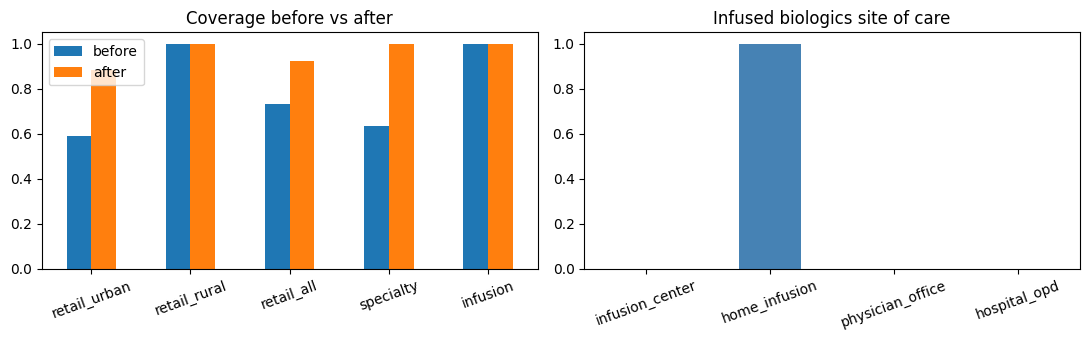

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
cb[['before','after']].plot.bar(ax=ax[0], rot=20); ax[0].set_title('Coverage before vs after'); ax[0].set_ylim(0,1.05)
pd.Series(M['mix']['INFUSED_BIO']).plot.bar(ax=ax[1], rot=20, color='steelblue')
ax[1].set_title('Infused biologics site of care'); plt.tight_layout(); plt.show()

## 14. The frontier: sweep the disruption dial [OUTPUT 6]

   lambda_D  savings_pct  disrupted_pct  kept_pct  cov_retail  sites  solve_s
0         0         10.1            0.0       8.8        92.3     49      5.6
1        20         10.1            0.0       8.8        92.3     49      5.4
2       200         10.1            0.0       8.8        92.3     49      5.2


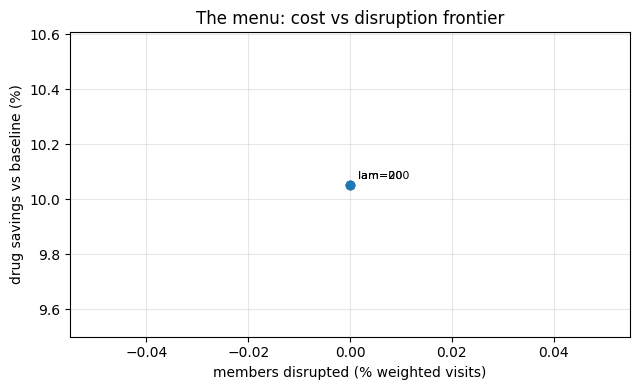

In [20]:
rows = []
for lam in CONFIG['LAMBDA_SWEEP']:
    P = dict(CONFIG); P['LAMBDA_D'] = lam
    set_objective(mdl, P); set_budget(mdl, None)
    r_, t_ = solve(mdl); Mi = metrics(mdl)
    rows.append(dict(lambda_D=lam, savings_pct=100*(1-Mi['drug']/B0), disrupted_pct=Mi['disr_pct'],
                     kept_pct=Mi['kept_pct'], cov_retail=100*Mi['cov_after']['retail_all'],
                     sites=len(Mi['selected']), solve_s=round(t_,1)))
front = pd.DataFrame(rows); print(front.round(1))
plt.figure(figsize=(6.5,4)); plt.plot(front.disrupted_pct, front.savings_pct, 'o-')
for _, r_ in front.iterrows():
    plt.annotate(f"lam={r_.lambda_D:.0f}", (r_.disrupted_pct, r_.savings_pct), textcoords='offset points', xytext=(6,4), fontsize=8)
plt.xlabel('members disrupted (% weighted visits)'); plt.ylabel('drug savings vs baseline (%)')
plt.title('The menu: cost vs disruption frontier'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 15. Scenario suite, reference script format

The base run defines base_cost, then five named scenarios at budget multiples of it, each with its own
weights, reporting coverage before, after, and delta alongside cost, disruption, continuity, and contract
percentage.

In [21]:
def build_scenarios(base_cost):
    return [
      dict(name='Lowest Cost',        budget=int(base_cost*1.002), LAMBDA_D=2.0,  CONTRACT_WEIGHT=2.0, DISTANCE_PENALTY=0.05, EXTRA_CHOICE_REWARD=0.0, CURRENT_NETWORK_REWARD=0.0),
      dict(name='Mid Cost',           budget=int(base_cost*1.20),  LAMBDA_D=6.0,  CONTRACT_WEIGHT=2.5, DISTANCE_PENALTY=0.05, EXTRA_CHOICE_REWARD=1.0, CURRENT_NETWORK_REWARD=0.5),
      dict(name='Better Coverage',    budget=int(base_cost*1.45),  LAMBDA_D=10.0, CONTRACT_WEIGHT=3.0, DISTANCE_PENALTY=0.05, EXTRA_CHOICE_REWARD=3.0, CURRENT_NETWORK_REWARD=1.0),
      dict(name='Highest Cost',       budget=int(base_cost*1.80),  LAMBDA_D=14.0, CONTRACT_WEIGHT=3.5, DISTANCE_PENALTY=0.04, EXTRA_CHOICE_REWARD=5.0, CURRENT_NETWORK_REWARD=1.5),
      dict(name='Biggest Percentage', budget=int(base_cost*2.10),  LAMBDA_D=8.0,  CONTRACT_WEIGHT=9.0, DISTANCE_PENALTY=0.02, EXTRA_CHOICE_REWARD=1.0, CURRENT_NETWORK_REWARD=0.5),
    ]
def solve_scenario(s):
    P = dict(CONFIG); P.update({k_:v for k_,v in s.items() if k_ in
             ('LAMBDA_D','CONTRACT_WEIGHT','DISTANCE_PENALTY','EXTRA_CHOICE_REWARD','CURRENT_NETWORK_REWARD')})
    set_objective(mdl, P); set_budget(mdl, s.get('budget'))
    r_, t_ = solve(mdl); Mi = metrics(mdl)
    return dict(scenario=s['name'], status=str(r_.solver.termination_condition), selected_count=len(Mi['selected']),
                total_network_cost=round(Mi['total']), drug_savings_pct=round(100*(1-Mi['drug']/B0),1),
                coverage_before_pct=round(coverage_before['retail_all'],3),
                coverage_after_pct=round(Mi['cov_after']['retail_all'],3),
                coverage_delta_pct=round(Mi['cov_after']['retail_all']-coverage_before['retail_all'],3),
                weighted_disruption_rate=round(Mi['disr_pct'],1), kept_current_pct=round(Mi['kept_pct'],1),
                weighted_assigned_contract_pct=round(Mi['contract_pct'],1), solve_s=round(t_,1)), Mi
base_summary, base_M = solve_scenario(dict(name='Base_LowestCost', budget=None, LAMBDA_D=2.0, CONTRACT_WEIGHT=2.0,
                                           DISTANCE_PENALTY=0.05, EXTRA_CHOICE_REWARD=0.0, CURRENT_NETWORK_REWARD=0.0))
base_cost = base_summary['total_network_cost']
scenario_outputs, scenario_metrics = [], {}
for s in build_scenarios(base_cost):
    summ, Mi = solve_scenario(s); scenario_outputs.append(summ); scenario_metrics[s['name']] = Mi
summary_df = pd.DataFrame(scenario_outputs)
print('=== Scenario Summary ===')
print(summary_df.to_string(index=False))

=== Scenario Summary ===
          scenario  status  selected_count  total_network_cost  drug_savings_pct  coverage_before_pct  coverage_after_pct  coverage_delta_pct  weighted_disruption_rate  kept_current_pct  weighted_assigned_contract_pct  solve_s
       Lowest Cost optimal              49             6014532              10.1                0.734               0.923                0.19                       0.0               9.0                            86.7      5.6
          Mid Cost optimal              49             6014532              10.1                0.734               0.923                0.19                       0.0               8.8                            86.8      5.5
   Better Coverage optimal              49             6014532              10.1                0.734               0.923                0.19                       0.0               8.6                            86.8      5.4
      Highest Cost optimal              49             6014532     

## 16. Scenario plots

Per scenario network map on the real Minneapolis geography, then the four panel comparison in the reference
script's layout.

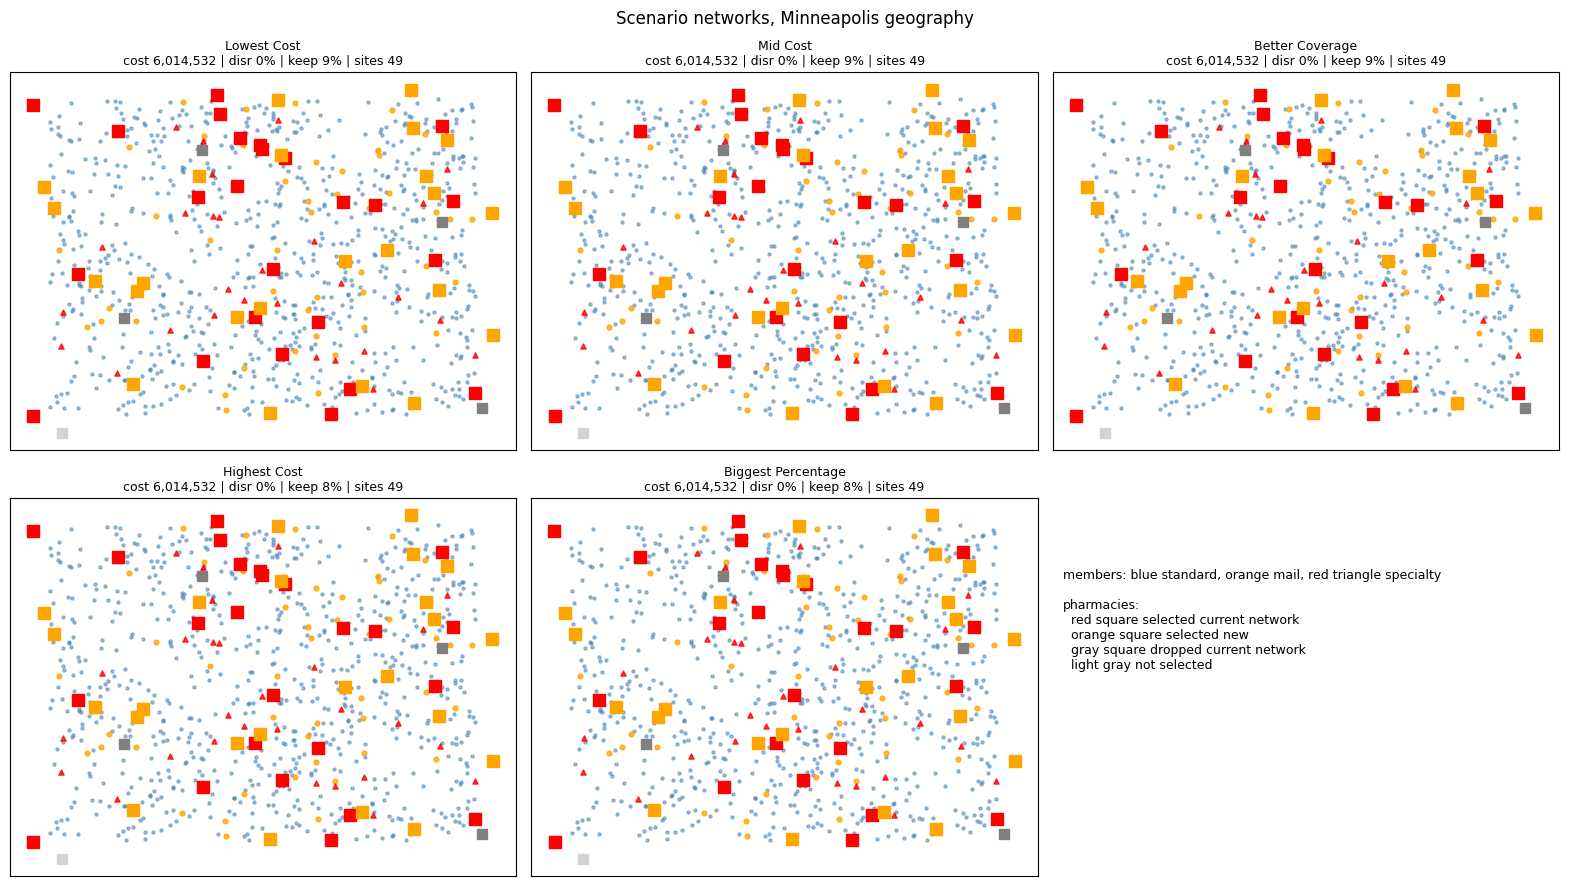

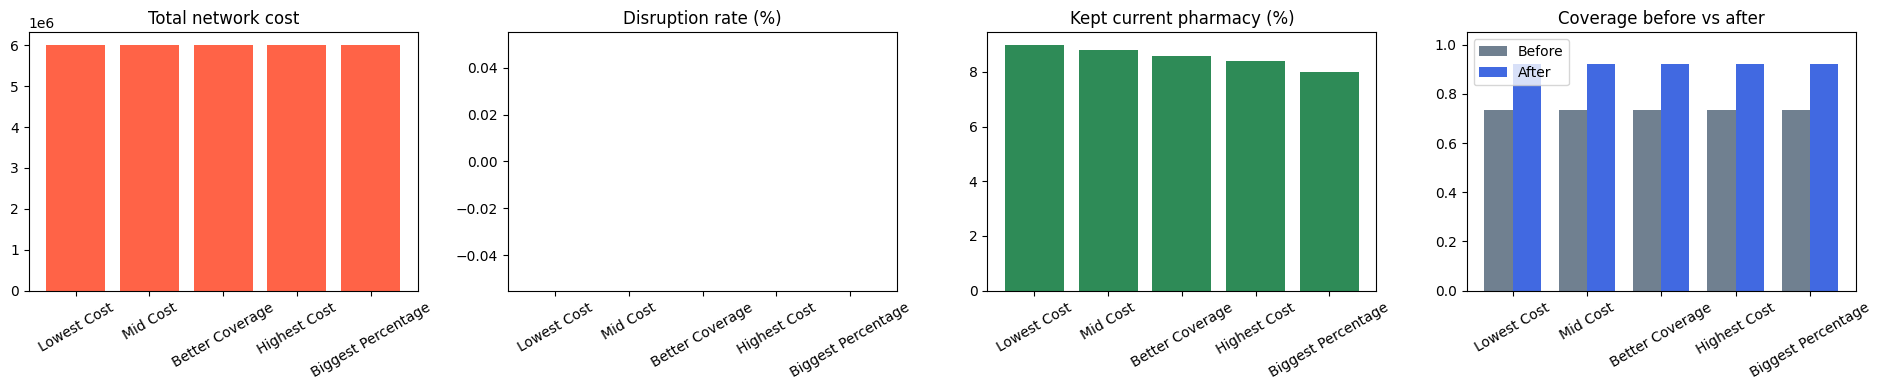

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, Mi) in zip(axes.flat, scenario_metrics.items()):
    sel = set(Mi['selected'])
    std_m = mem.loc[STD]; sp_m = mem.loc[SPECM]; ml_m = mem.loc[MAILM]
    ax.scatter(std_m.lon, std_m.lat, s=5, c='steelblue', alpha=0.5)
    ax.scatter(ml_m.lon,  ml_m.lat,  s=12, c='orange', alpha=0.8)
    ax.scatter(sp_m.lon,  sp_m.lat,  s=14, c='red', marker='^', alpha=0.8)
    rs = ph.loc[[p for p in SITES]]
    drop_cur = rs[(rs.in_current_network==1) & (~rs.index.isin(sel))]
    other    = rs[(rs.in_current_network==0) & (~rs.index.isin(sel))]
    sel_cur  = rs[(rs.in_current_network==1) & (rs.index.isin(sel))]
    sel_new  = rs[(rs.in_current_network==0) & (rs.index.isin(sel))]
    ax.scatter(other.lon, other.lat, s=45, c='lightgray', marker='s')
    ax.scatter(drop_cur.lon, drop_cur.lat, s=55, c='gray', marker='s')
    ax.scatter(sel_cur.lon, sel_cur.lat, s=65, c='red', marker='s')
    ax.scatter(sel_new.lon, sel_new.lat, s=65, c='orange', marker='s')
    ax.set_title(f"{name}\ncost {Mi['total']:,.0f} | disr {Mi['disr_pct']:.0f}% | keep {Mi['kept_pct']:.0f}% | sites {len(sel)}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
axes.flat[-1].axis('off')
axes.flat[-1].text(0.02, 0.55, 'members: blue standard, orange mail, red triangle specialty\n\n'
                               'pharmacies:\n  red square selected current network\n  orange square selected new\n'
                               '  gray square dropped current network\n  light gray not selected', fontsize=9)
plt.suptitle('Scenario networks, Minneapolis geography'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(19, 4))
axes[0].bar(summary_df.scenario, summary_df.total_network_cost, color='tomato'); axes[0].set_title('Total network cost')
axes[1].bar(summary_df.scenario, summary_df.weighted_disruption_rate, color='goldenrod'); axes[1].set_title('Disruption rate (%)')
axes[2].bar(summary_df.scenario, summary_df.kept_current_pct, color='seagreen'); axes[2].set_title('Kept current pharmacy (%)')
xp = np.arange(len(summary_df)); wd = 0.38
axes[3].bar(xp-wd/2, summary_df.coverage_before_pct, wd, color='slategray', label='Before')
axes[3].bar(xp+wd/2, summary_df.coverage_after_pct,  wd, color='royalblue', label='After')
axes[3].set_xticks(xp); axes[3].set_xticklabels(summary_df.scenario); axes[3].set_ylim(0,1.05)
axes[3].set_title('Coverage before vs after'); axes[3].legend(loc='best')
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()